In [46]:
import scipy.io
import pandas as pd
import numpy as np
from tqdm import tqdm
from utils.dynamicRieszFunctions_org import *
import joblib
import pickle
river_data = pd.read_csv("data/river_data.csv") # experimental
other_data = pd.read_csv("data/others_data.csv") # observational
# Define pretreatment variables
pretreat_vars = (
    [f"paid{i}" for i in range(1, 5)] +         # 4 lagged values for aid
    [f"tcpp{i}" for i in range(1, 11)] +        # 10 lagged values for employment
    [f"tcprn{i}" for i in range(1, 11)]         # 10 lagged values for earnings
)
def difference_of_means(treated,  control):

    treated = np.asarray(treated)
    control = np.asarray(control)

    n_t = len(treated)
    n_c = len(control)

    mean_t = np.mean(treated)
    mean_c = np.mean(control)

    var_t = np.var(treated)  # sample variance
    var_c = np.var(control)

    diff = mean_t - mean_c
    se = np.sqrt(var_t / n_t + var_c / n_c)

    return diff, se
def ci(point, sigma):
    ub = point + 1.96 * sigma
    lb = point - 1.96 * sigma 
    return ub, lb
# List of used covariates
covariates = [
    "xsexf", "xhsdip", "xchld05", "single",
    "grd1720", "grade16", "grd1315", "grade12", "grde911", "white",
    "hisp", "black", "age"
] + pretreat_vars
def create_dataset(quarters, application):
    if application not in ["earn", "employ"]:
        raise ValueError
    Y_obsorved = other_data[f"Y_{application}"]
    Y_experimental = river_data[f"Y_{application}"] # not used in fitting, only to evaluate
    if application == "employ":
        s_colums = (
            [f"{application}{i}" for i in range(1, quarters+ 1)] +
            [f"aid{i}" for i in range(1, quarters+ 1)] +
            [f"earn{i}" for i in range(1, quarters + 1)]
        )
    elif application == "earn":
        s_colums = (
            [f"{application}{i}" for i in range(1, quarters+ 1)] +
            [f"aid{i}" for i in range(1, quarters + 1)]
        )

    S_obs = other_data[s_colums]
    S_exp = river_data[s_colums]
    D_exp = river_data["e"]
    D_obs = other_data["e"]
    X_obs = other_data[covariates]
    X_exp = river_data[covariates]
    Y_all = pd.concat([Y_obsorved, Y_experimental], axis=0).reset_index(drop=True)
    X_all = pd.concat([X_obs, X_exp], axis=0).reset_index(drop=True)
    S_all = pd.concat([S_obs, S_exp], axis=0).reset_index(drop=True)
    D_all = pd.concat([D_obs, D_exp], axis=0).reset_index(drop=True)
    G_all = pd.concat([
        pd.Series(np.ones(len(D_obs))),
        pd.Series(np.zeros(len(D_exp)))
    ], axis=0).reset_index(drop=True)

    Y_all_torch = torch.tensor(Y_all.values, dtype=torch.float64).view(-1, 1)
    X_all_torch = torch.tensor(X_all.values, dtype=torch.float64)
    S_all_torch = torch.tensor(S_all.values, dtype=torch.float64)
    D_all_torch = torch.tensor(D_all.values, dtype=torch.float64).view(-1, 1)
    G_all_torch = torch.tensor(G_all.values, dtype=torch.float64).view(-1, 1)
    return {"Y_obsorved": Y_obsorved,"Y_experimental": Y_experimental, "S_obs": S_obs, "S_exp":S_exp,
            "D_exp": D_exp, "D_ops":D_obs, "X_obs": X_obs, "X_exp": X_exp, "Y_all" : Y_all_torch, "X_all": X_all_torch, "S_all": S_all_torch, "D_all": D_all_torch, "G_all": G_all_torch,
            "names_x":covariates, "names_z":s_colums }
ds =create_dataset(6,"earn")

In [47]:
Y_exp= ds["Y_experimental"]
D_exp = ds["D_exp"]
true_effect, true_sd  =difference_of_means(Y_exp[D_exp == 1], Y_exp[D_exp ==0])
print(true_effect, f"({true_sd})")

249.0544297398368 (51.038236817705666)


In [48]:
n = ds["S_all"].shape[0]

In [49]:
import re
import numpy as np
import matplotlib.pyplot as plt

def plot_estimators(atts_athey, stds_athey, ATT, robust_bounds, caption,
                    exclude_last=0, extra_estimators=None):

    def ci(estimates, stds, z=1.96):
        upper = estimates + z * stds
        lower = estimates - z * stds
        return upper, lower

    # Compute bounds for main estimators
    athey_bounds = ci(atts_athey, stds_athey)
    benchmark_bounds = ci(true_effect, true_sd)

    # Combine all estimates
    all_estimates = np.concatenate(([true_effect], atts_athey, ATT))
    all_upper = np.concatenate(([benchmark_bounds[0]], athey_bounds[0], np.squeeze(robust_bounds[0])))
    all_lower = np.concatenate(([benchmark_bounds[1]], athey_bounds[1], np.squeeze(robust_bounds[1])))

    labels = [
        "Benchmark", 
        "Naive", 
        "Surrogacy Index", 
        "Surrogacy Score", 
        "Influence Function", 
        "Nested Riesz (LASSO)", 
        "Nested Riesz (RF)", 
        "Nested Riesz (Net)"
    ]

   

    # Start plot
    plt.figure(figsize=(15, 5))
    plt.errorbar(
        x=labels, y=all_estimates,
        yerr=[all_estimates - all_lower, all_upper - all_estimates],
        fmt='o', capsize=5, color='blue', ecolor='gray', elinewidth=2
    )

    # Optionally add extra estimators
    if extra_estimators is not None and len(extra_estimators) > 0:
        extra_labels = list(extra_estimators.keys())
        extra_means = np.array([v[0] for v in extra_estimators.values()])
        extra_bounds = np.array([v[2] for v in extra_estimators.values()])
        extra_lower = extra_bounds[:, 0]
        extra_upper = extra_bounds[:, 1]

        if exclude_last > 0:
            extra_labels = extra_labels[:-exclude_last]
            extra_means = extra_means[:-exclude_last]
            extra_lower = extra_lower[:-exclude_last]
            extra_upper = extra_upper[:-exclude_last]

        plt.errorbar(
            x=extra_labels, y=extra_means,
            yerr=[extra_means - extra_lower, extra_upper - extra_means],
            fmt='o', capsize=5, color='red', ecolor='gray', elinewidth=2
        )

        labels = labels + extra_labels  # optional if you need combined tick control

    plt.ylabel('Point Estimate')
    plt.title(caption)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


estimates = pd.read_csv("application_results_final/q6.csv")
atts_athey_6= np.array([327.1, 238.8,  279.7,  280.6])
stds_athey_6  =np.array( [36.6, 31.5, 32.5, 32.9])

ATT_6  = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates.iloc[:, ::2].values.flatten()]

std_6 = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates.iloc[:, 1::2].values.flatten()]

robust_bounds = ci(ATT_6, std_6/np.sqrt(n))


In [50]:
ATT_6

[203.8262, 240.6666, 263.7033]

In [51]:
with open("../NNIPV/results_nnpiv_earnings.pkl", "rb") as f:
    results = pickle.load(f)

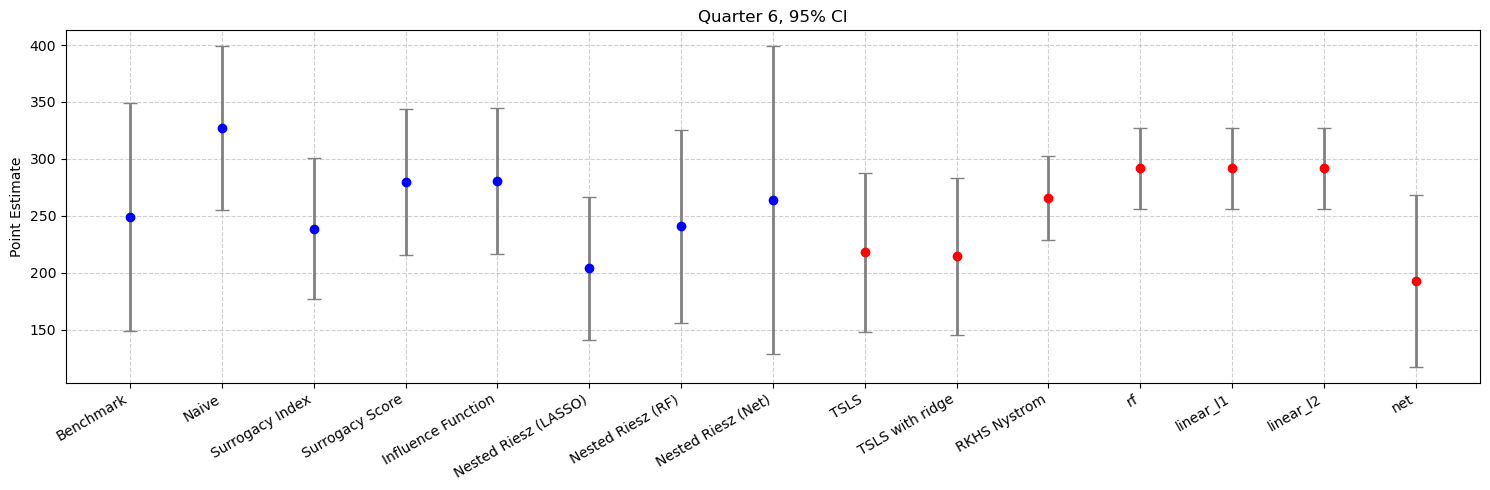

In [52]:
plot_estimators(atts_athey_6,stds_athey_6, ATT_6, robust_bounds, "Quarter 6, 95% CI", extra_estimators=results)

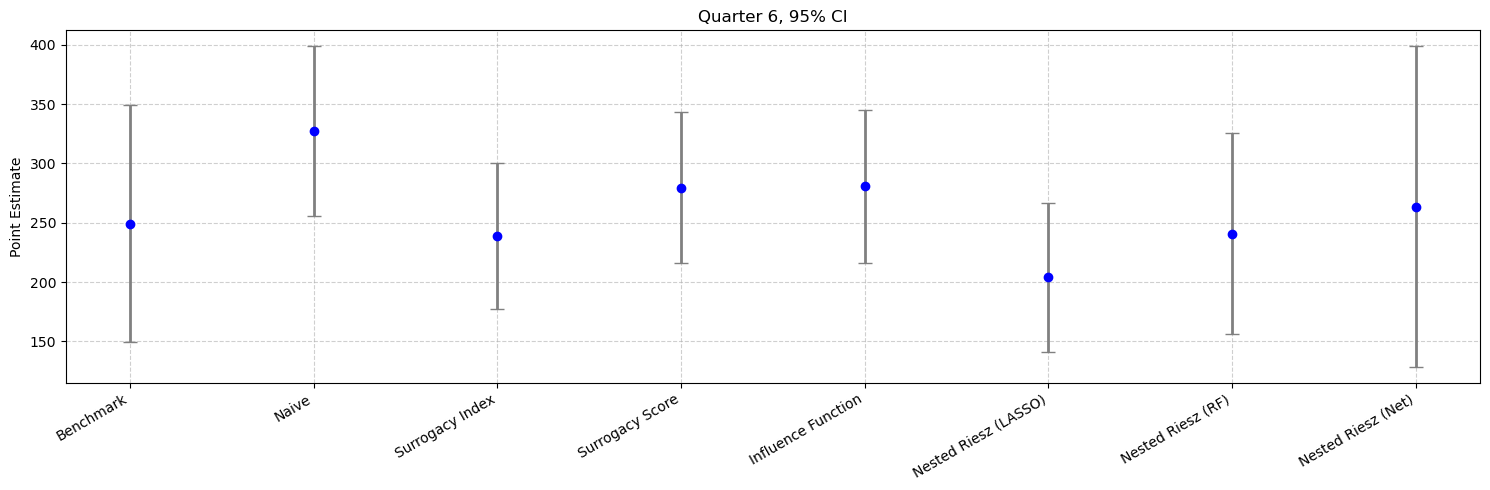

In [53]:
plot_estimators(atts_athey_6,stds_athey_6, ATT_6, robust_bounds, "Quarter 6, 95% CI",2)

## q 5

In [54]:
estimates = pd.read_csv("application_results_final/q5.csv")


ATT_5 = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates.iloc[:, ::2].values.flatten()]

std_5 = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates.iloc[:, 1::2].values.flatten()]


In [55]:
ATT_5

[196.9109, 193.9707, 222.833]

In [56]:
std_5

[4027.2623, 6351.4308, 9539.9452]

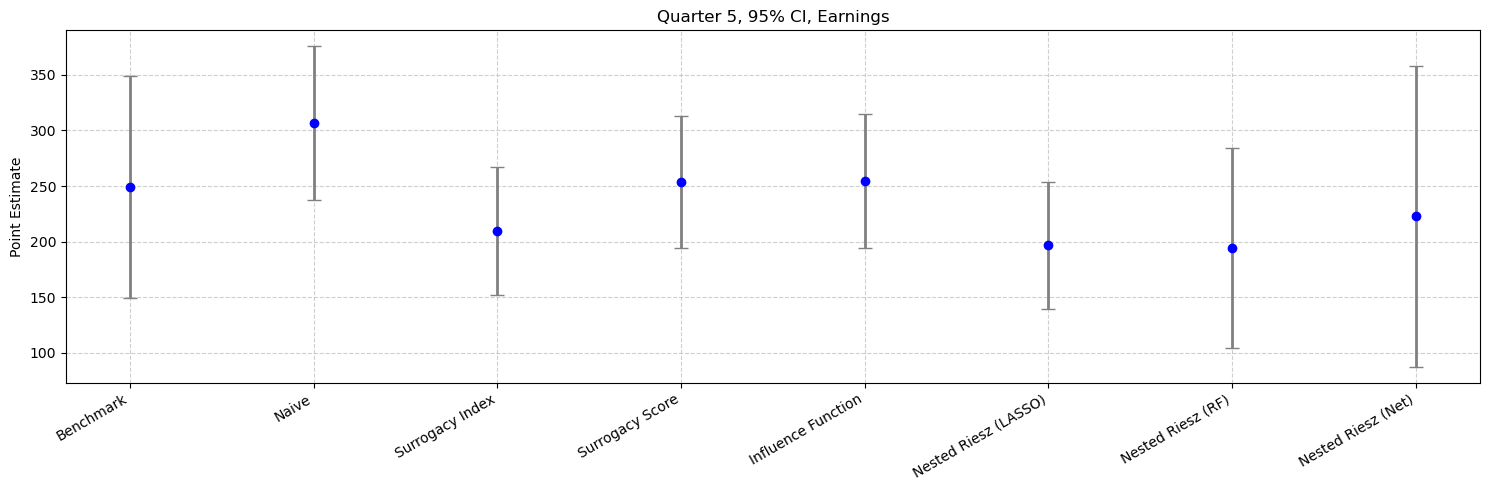

In [57]:
atts_athey_5 = np.array([ 306.5 , 209.6 ,  253.4,  254.4])
stds_athey_5  =np.array( [35.2, 29.5, 30.3,30.7])
robust_bounds = ci(ATT_5, std_5/np.sqrt(n))

plot_estimators(atts_athey_5,stds_athey_5, ATT_5, robust_bounds, "Quarter 5, 95% CI, Earnings",0)

## Employ

In [58]:
import pickle
ds = create_dataset(6, "employ")
Y_exp= ds["Y_experimental"]
D_exp = ds["D_exp"]
true_effect, true_sd  =difference_of_means(Y_exp[D_exp == 1], Y_exp[D_exp ==0])
print(true_effect, f"({true_sd})")
with open("../NNIPV/results_nnpiv.pkl", "rb") as f:
    results = pickle.load(f)

0.06370271132260347 (0.009934125675486934)


In [59]:
estimates = pd.read_csv("application_results_final/employ_q6.csv")
atts_athey_6= np.array([0.117, 0.061,  0.063,   0.065])
stds_athey_6  =np.array( [  0.010,  0.006, 0.006, 0.006])

ATT_6  = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates.iloc[:, ::2].values.flatten()]

std_6 = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates.iloc[:, 1::2].values.flatten()]

robust_bounds = ci(ATT_6, std_6/np.sqrt(n))


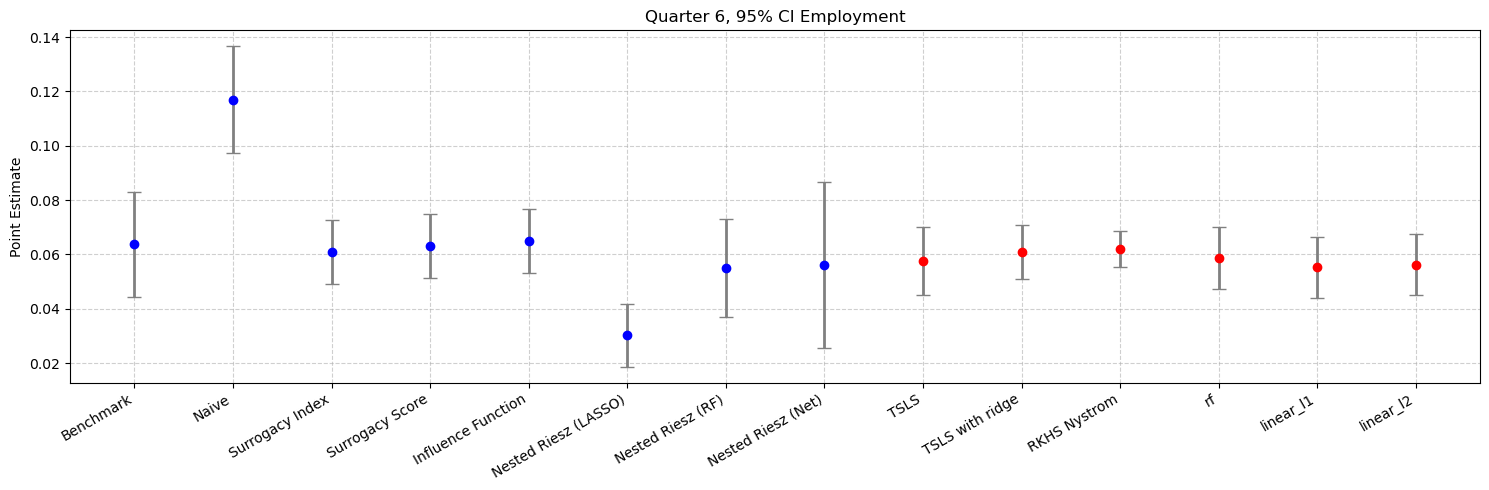

In [60]:
plot_estimators(atts_athey_6,stds_athey_6, ATT_6, robust_bounds, "Quarter 6, 95% CI Employment", exclude_last=1 ,extra_estimators=results)